# House Price Prediction
Complete, reproducible workflow using the supplied Kaggle CSV.

## 1. Load & Inspect

The dataset contains 187,531 rows and 21 columns.

The numeric columns are:
- `Index`
- `Price (in rupees)`
- `Dimensions`
- `Plot Area`

The remaining 17 columns are text/categorical (`object`) columns.

The columns with the highest percentage of missing values are:
- `Dimensions`: 100%
- `Plot Area`: 100%
- `Society`: 58.5%
- `Super Area`: 57.4%
- `Car Parking`: 55.1%

The modeling target is `Amount(in rupees)`, which is stored as text values such as `42 Lac` and `1.40 Cr`, so it will be converted to numeric INR during cleaning.

In [3]:
from pathlib import Path
import os, sys, pandas as pd
os.chdir(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd())
sys.path.insert(0, str(Path.cwd()))
from src.training import clean_data, train_and_export
raw = pd.read_csv('data/house_prices.csv')
display(raw.shape, raw.head(), raw.info(), raw.describe(include='all'), raw.isna().mean().sort_values(ascending=False))

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

(187531, 21)

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


None

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
count,187531.000000,187531,184508,187531,1.698660e+05,187531,106858,186916,180454,187448,...,117298,106095,77853,186703,138596,84174,122014,79846,0.0,0.0
unique,NaN,32446,65634,1561,NaN,81,2758,1,947,4,...,8,19,10376,11,11,229,4,2976,NaN,NaN
top,NaN,2 BHK Ready to Occupy Flat for sale in Divyasr...,Multistorey apartment is available for sale. I...,Call for Price,NaN,new-delhi,1000 sqft,Ready to Move,2 out of 4,Resale,...,East,Main Road,Hamdam Apartment,2,2,1 Covered,Freehold,1100 sqft,NaN,NaN
freq,NaN,2106,2732,9684,NaN,27599,5285,186916,12433,144172,...,54741,32193,1648,93007,51809,38754,112229,2599,NaN,NaN
mean,93765.000000,NaN,NaN,NaN,7.583772e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,54135.681003,NaN,NaN,NaN,2.724171e+04,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,46882.500000,NaN,NaN,NaN,4.297000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,93765.000000,NaN,NaN,NaN,6.034000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,140647.500000,NaN,NaN,NaN,9.450000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

In [6]:
data = clean_data(raw)

display(data.head())
print(data.shape)
print(data.columns.tolist())

,location,Status,Transaction,Furnishing,facing,Ownership,price_clean,carpet_area_sqft,floor_num,bathroom,balcony,car_parking,location_grouped
0,thane,Ready to Move,Resale,Unfurnished,NaN,NaN,4200000.0,500.0,10.0,1.0,2.0,NaN,thane
1,thane,Ready to Move,Resale,Semi-Furnished,East,Freehold,9800000.0,473.0,3.0,2.0,NaN,1.0,thane
2,thane,Ready to Move,Resale,Unfurnished,East,Freehold,14000000.0,779.0,10.0,2.0,NaN,1.0,thane
3,thane,Ready to Move,Resale,Unfurnished,NaN,NaN,2500000.0,530.0,1.0,1.0,1.0,NaN,thane
4,thane,Ready to Move,Resale,Unfurnished,West,Co-operative Society,16000000.0,635.0,20.0,2.0,NaN,1.0,thane


(176293, 13)
['location', 'Status', 'Transaction', 'Furnishing', 'facing', 'Ownership', 'price_clean', 'carpet_area_sqft', 'floor_num', 'bathroom', 'balcony', 'car_parking', 'location_grouped']


## 2. Exploratory Data Analysis
The dataset is explored using four visualizations to understand the target price and its relationship with important property features.

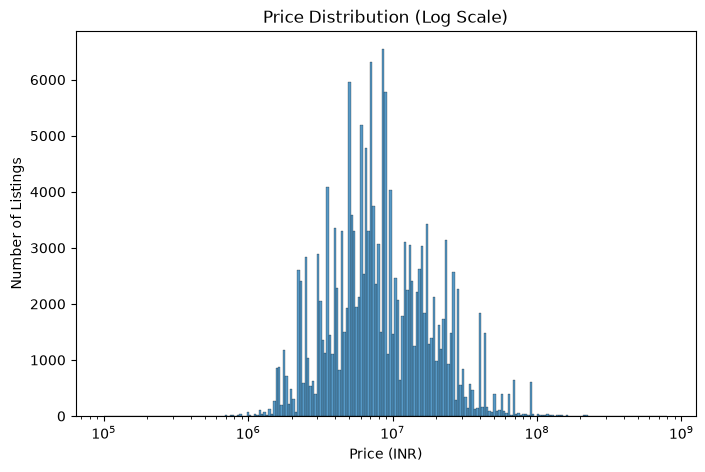

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of the target price
plt.figure(figsize=(8, 5))
sns.histplot(data["price_clean"], log_scale=True)
plt.title("Price Distribution (Log Scale)")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Listings")
plt.show()

### Interpretation — Price Distribution

The price distribution is strongly right-skewed, meaning that most properties are concentrated at lower and medium price levels while a smaller number of properties have very high prices. Using a logarithmic scale makes the distribution easier to visualize and compare.

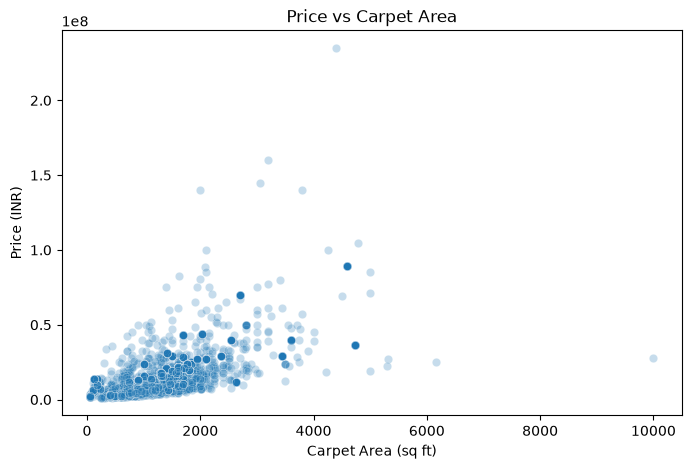

In [8]:
sample_data = data.sample(min(10000, len(data)), random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=sample_data,
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.25
)
plt.title("Price vs Carpet Area")
plt.xlabel("Carpet Area (sq ft)")
plt.ylabel("Price (INR)")
plt.show()

### Interpretation — Price vs Carpet Area

The scatter plot shows a general positive relationship between carpet area and price: larger properties tend to have higher prices. However, the points are widely scattered, indicating that other factors such as location, furnishing, and property characteristics also influence price.

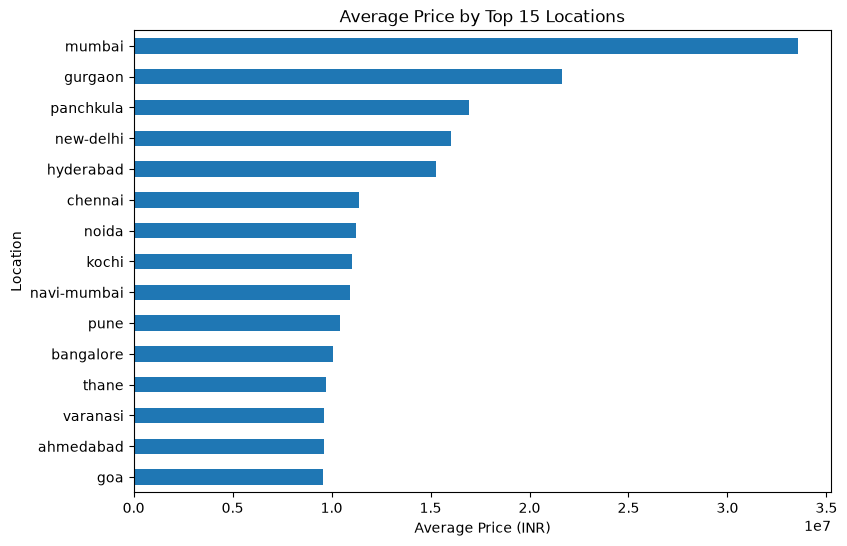

In [9]:
top_locations = (
    data[data["location_grouped"] != "other"]
    .groupby("location_grouped")["price_clean"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

plt.figure(figsize=(9, 6))
top_locations.plot.barh()
plt.title("Average Price by Top 15 Locations")
plt.xlabel("Average Price (INR)")
plt.ylabel("Location")
plt.show()

### Interpretation — Average Price by Location

Average property prices vary considerably across locations. Some locations have substantially higher average prices than others, showing that location is an important categorical feature for predicting house prices.

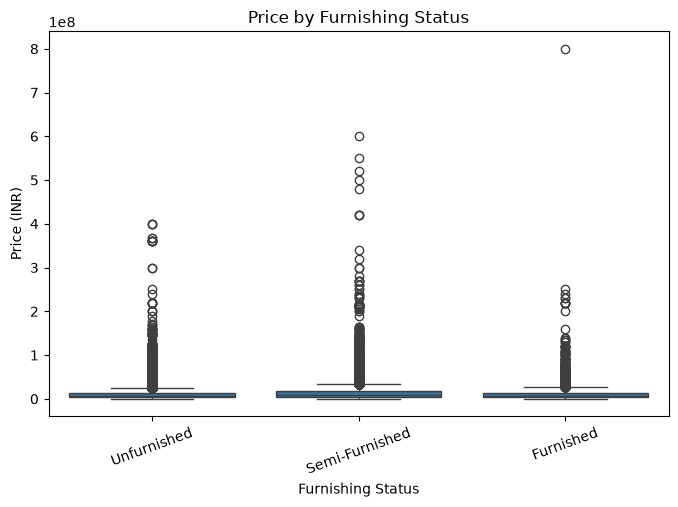

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=data,
    x="Furnishing",
    y="price_clean"
)
plt.title("Price by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Price (INR)")
plt.xticks(rotation=20)
plt.show()

### Interpretation — Price by Furnishing Status

The box plot shows differences in the distribution of prices across furnishing categories. Furnished and semi-furnished properties can have different price ranges compared with unfurnished properties, suggesting that furnishing status may contribute useful information to the prediction model.

## 3. Cleaning & Feature Engineering

The raw dataset contains several text-based and incomplete fields, so the data is cleaned and transformed into model-ready features.

The following steps are performed:

1. **Target price conversion:** `Amount(in rupees)` is converted into numeric INR values. Values such as `42 Lac` and `1.40 Cr` are converted using:
   - 1 Lac = 100,000 INR
   - 1 Cr = 10,000,000 INR
   Rows without a usable target price are removed.

2. **Carpet area conversion:** `Carpet Area` values are converted to numeric square feet. Values given in square metres are converted using 1 sqm ≈ 10.764 sqft.

3. **Floor extraction:** The current floor number is extracted from values such as `10 out of 11`. `Ground` is represented as 0 and `Basement` as -1.

4. **Numeric feature extraction:** `Bathroom`, `Balcony`, and `Car Parking` are converted from text values into numeric features. Missing values are handled later by the preprocessing pipeline using median imputation.

5. **Location grouping:** Only the 50 most frequent locations are retained. All other locations are grouped into `other` to reduce high-cardinality categorical features.

6. **Outlier removal:** Price-per-square-foot is calculated where a valid carpet area exists. Listings outside the 1st and 99th percentiles are removed.

7. **Column removal:** Identifier, free-text, raw pre-engineering, high-cardinality, unused, and completely empty columns are removed. This includes `Index`, `Title`, `Description`, `Society`, `Dimensions`, `Plot Area`, `overlooking`, and the original raw feature columns.

8. **Super Area:** `Super Area` is excluded because approximately 57.4% of its values are missing and it overlaps with the better-defined `Carpet Area` feature.

The resulting DataFrame contains the cleaned target and engineered features used by the machine-learning pipeline.

In [19]:
display(
    data[
        [
            "price_clean",
            "carpet_area_sqft",
            "floor_num",
            "bathroom",
            "balcony",
            "car_parking",
            "location_grouped",
        ]
    ].head()
)

print("Original shape:", raw.shape)
print("Cleaned shape:", data.shape)
print("Rows removed:", raw.shape[0] - data.shape[0])

,price_clean,carpet_area_sqft,floor_num,bathroom,balcony,car_parking,location_grouped
0,4200000.0,500.0,10.0,1.0,2.0,NaN,thane
1,9800000.0,473.0,3.0,2.0,NaN,1.0,thane
2,14000000.0,779.0,10.0,2.0,NaN,1.0,thane
3,2500000.0,530.0,1.0,1.0,1.0,NaN,thane
4,16000000.0,635.0,20.0,2.0,NaN,1.0,thane


Original shape: (187531, 21)
Cleaned shape: (176293, 13)
Rows removed: 11238


## 4. Pipeline & Training

A scikit-learn `Pipeline` is used so that preprocessing and model training are bundled together. This ensures that the same preprocessing steps are applied during both training and prediction.

A `ColumnTransformer` is used for two types of features:

**Numeric features**
- `carpet_area_sqft`
- `floor_num`
- `bathroom`
- `balcony`
- `car_parking`

Missing numeric values are imputed using the median and the features are standardized using `StandardScaler`.

**Categorical features**
- `location_grouped`
- `Furnishing`
- `Transaction`
- `Ownership`
- `facing`

Missing categorical values are imputed using the most frequent value and categorical values are converted using `OneHotEncoder(handle_unknown="ignore")`.

Two regression models are trained and evaluated using the same 80/20 train-test split with `random_state=42`:

1. `LinearRegression` — used as a baseline model.
2. `RandomForestRegressor` — used as the main non-linear model.

The model with the lowest RMSE on the held-out test set is selected as the final model.

In [20]:
results = train_and_export(
    "data/house_prices.csv",
    "models"
)

display(results["comparison"])

,model,MAE,RMSE,R2
0,RandomForestRegressor,1.373404e+06,5.530531e+06,0.836545
1,LinearRegression,4.713675e+06,8.788458e+06,0.587246


## 5. Evaluation
The comparison table contains MAE, RMSE, and R² calculated on the test set. The lowest-RMSE model is selected. The predicted-vs-actual plot should lie close to the diagonal when estimates are accurate.

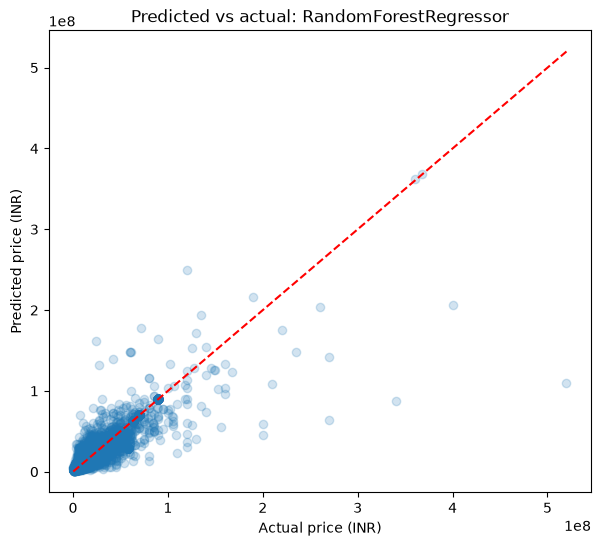

In [21]:
plt.figure(figsize=(7,6)); plt.scatter(results['y_test'], results['predictions'], alpha=.2); limits=[min(results['y_test'].min(), results['predictions'].min()), max(results['y_test'].max(), results['predictions'].max())]; plt.plot(limits, limits, 'r--'); plt.title(f'Predicted vs actual: {results["best_name"]}'); plt.xlabel('Actual price (INR)'); plt.ylabel('Predicted price (INR)'); plt.show()

## 6. Export
`models/house_price.pkl` is the complete fitted pipeline. `models/locations.json` supplies the frontend dropdown. The training function reloads the saved model and predicts one test sample as a sanity check.

In [22]:
print('Selected model:', results['best_name']); print('Reloaded-pipeline prediction:', results['reload_prediction']); print('Exported:', list(Path('models').glob('*')))

Selected model: RandomForestRegressor
Reloaded-pipeline prediction: 10584166.666666668
Exported: [WindowsPath('models/house_price.pkl'), WindowsPath('models/locations.json'), WindowsPath('models/model_metrics.csv'), WindowsPath('models/training_metadata.json')]
